## 1. What this notebook computes

This notebook builds the numbers that the course computes with, from whole
numbers to the floating-point numbers of a computer, and the powers, roots,
exponentials and logarithms that the author's metric is made of. It

- computes exactly with whole numbers and fractions;
- turns fractions into decimals by long division and shows that their digits
  always end or repeat (with a plot of the length of the repeating part);
- proves that $\sqrt 2$ is not a fraction, pins it down between fractions by
  halving an interval, and finds the best fractions near it;
- shows how a computer stores a real number (a *floating-point number*), why
  $0.1 + 0.2$ is not exactly $0.3$ in a computer, how far apart neighbouring
  floating-point numbers are, and how a careless formula loses all its digits
  (*cancellation*);
- checks the laws of powers and roots, and uses them to turn the diagonal of
  the author's metric into the eight length factors, whose product is the square
  root of the size of the determinant stored in the Revision record;
- builds the number $e$ and the exponential function as a limit, and shows the
  growth $e^{a_4}$ of space and the exponential deflation $e^{-a_4}$ of the
  three extra times on ordinary and on logarithmic axes.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01f (Numbers: fractions, real numbers, floating point and powers) is the file
`Revision/textbook/notebooks/01f_numbers_and_powers.ipynb` of the repository
Dirac_claude. It computes exactly with whole numbers and fractions, turns fractions into
repeating decimals by long division, proves and checks that the square root of 2 is not a
fraction and pins it down by halving intervals and by its best fractions, shows how a
computer stores real numbers as floating-point numbers and what rounding and cancellation
do, checks the laws of powers and roots and uses them to turn the author's metric into
the length factors of the eight directions, whose product is the square root of the size
of its determinant recorded in the Revision record, and builds the exponential function
and the logarithm with the growth of space and the exponential deflation of the three
extra times on logarithmic axes. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy, mpmath and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01f_numbers_and_powers.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01f_numbers_and_powers.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01f_numbers_and_powers.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01f.captions.json`
- `Revision/textbook/figures/01f_1_decimal_periods.png`
- `Revision/textbook/figures/01f_2_square_root_of_two.png`
- `Revision/textbook/figures/01f_3_float_spacing.png`
- `Revision/textbook/figures/01f_4_cancellation.png`
- `Revision/textbook/figures/01f_5_limit_for_e.png`
- `Revision/textbook/figures/01f_6_growth_and_deflation.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 26 CHECKS PASSED (notebook 01f)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01f_numbers_and_powers.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 01f_numbers_and_powers.ipynb
      python -m nbconvert --execute --inplace 01f_numbers_and_powers.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/gkd_lovelock or Revision/algebra: the
  notebook reads Revision records of the repository; your copy of the repository is
  incomplete. Download it again with git clone and open the notebook inside the new copy.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01f (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01f (Numbers: fractions, real numbers, floating point and powers) is the file
# Revision/textbook/notebooks/01f_numbers_and_powers.ipynb of the repository
# Dirac_claude. It computes exactly with whole numbers and fractions, turns fractions
# into repeating decimals by long division, proves and checks that the square root of 2
# is not a fraction and pins it down by halving intervals and by its best fractions,
# shows how a computer stores real numbers as floating-point numbers and what rounding
# and cancellation do, checks the laws of powers and roots and uses them to turn the
# author's metric into the length factors of the eight directions, whose product is the
# square root of the size of its determinant recorded in the Revision record, and builds
# the exponential function and the logarithm with the growth of space and the exponential
# deflation of the three extra times on logarithmic axes. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy, mpmath and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01f_numbers_and_powers.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01f_numbers_and_powers.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01f_numbers_and_powers.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01f.captions.json
# - Revision/textbook/figures/01f_1_decimal_periods.png
# - Revision/textbook/figures/01f_2_square_root_of_two.png
# - Revision/textbook/figures/01f_3_float_spacing.png
# - Revision/textbook/figures/01f_4_cancellation.png
# - Revision/textbook/figures/01f_5_limit_for_e.png
# - Revision/textbook/figures/01f_6_growth_and_deflation.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 26 CHECKS PASSED (notebook 01f)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01f_numbers_and_powers.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 01f_numbers_and_powers.ipynb
#     python -m nbconvert --execute --inplace 01f_numbers_and_powers.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/gkd_lovelock or Revision/algebra: the
#   notebook reads Revision records of the repository; your copy of the repository is
#   incomplete. Download it again with git clone and open the notebook inside the new
#   copy.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01f"  # this notebook: chapter 01, example f


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01f complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Whole numbers** (integers): $\dots, -2, -1, 0, 1, 2, \dots$. Python computes
  with them exactly, however large they are.
- **Fraction** (rational number): $p/q$ with whole numbers $p$ and $q \neq 0$.
  It is in **lowest terms** when $p$ and $q$ have no common factor larger than 1.
  Python's `fractions.Fraction` computes with fractions exactly.
- **Greatest common divisor** $\gcd(p, q)$: the largest whole number that
  divides both $p$ and $q$ (`math.gcd`).
- **Long division**: the school method that produces the decimal digits of
  $p/q$ one after the other from the remainders.
- **Repeating decimal**: a decimal whose digits repeat a block for ever, written
  with the block in brackets: $1/7 = 0.(142857)$. The block's length is the
  **period**.
- **Prime number**: a whole number larger than 1 that only 1 and itself divide.
- **Real number**: a number on the number line; it may need infinitely many
  digits that do not repeat, like $\sqrt 2$ or $\pi$. Such a number is
  **irrational** (not a fraction).
- **Bisection**: halving an interval that contains the number again and again,
  keeping the half that still contains it.
- **Floating-point number**: the way a computer stores a real number: a whole
  number of 53 binary digits (bits) times a power of 2. Neighbouring
  floating-point numbers are a small step apart, so most real numbers are
  **rounded** to the nearest one.
- **Machine epsilon** $\varepsilon = 2^{-52} \approx 2.2 \times 10^{-16}$: the
  step from 1 to the next floating-point number.
- **Relative error**: $|$computed $-$ exact$|$ divided by $|$exact$|$.
- **Cancellation**: the loss of digits when two nearly equal numbers are
  subtracted.
- **Power** $a^p$ and **root** $a^{1/n}$; the **laws of powers**
  $a^p a^q = a^{p+q}$, $(a^p)^q = a^{pq}$, $(ab)^p = a^p b^p$,
  $a^{-p} = 1/a^p$ for positive $a, b$.
- **Absolute value** $|x|$: $x$ without its sign; $\sqrt{x^2} = |x|$.
- **Exponential function** $e^x$ and **natural logarithm** $\ln x$, which
  undoes it: $\ln(e^x) = x$. The number $e = 2.71828\dots$.
- **e-fold**: a growth by the factor $e$; a growth of $a_4$ by $\ln 2 \approx
  0.693$ doubles $e^{a_4}$ and halves $e^{-a_4}$.
- **Logarithmic axis**: an axis on which each step multiplies by 10, so that
  an exponential function is a straight line.
- **mpmath**: a Python package that computes with as many decimal digits as
  requested (here 50).

## 4. The physical and mathematical situation

The author's metric of the primordial gravitational field is the diagonal
matrix

$$g = \mathrm{diag}\big(e^{2a_4} s, e^{2a_4} s, e^{2a_4} s, -1,
-e^{-2a_4} s, -e^{-2a_4} s, -e^{-2a_4} s, \cot^2 z\big),\quad
s = \sin^{1/3} z,\ z = 6 H x_8,\ 0 < z < \pi/2.$$

Its entries are built from powers ($\sin^{1/3} z$ is the cube root of
$\sin z$), exponentials ($e^{2a_4}$) and a trigonometric function. A length
along a coordinate is the square root of the size of its metric entry: along
$x_1, x_2, x_3$ (space) it is $e^{a_4}\sin^{1/6} z$, which grows as $a_4$
grows, and along the three extra times $x_5, x_6, x_7$ it is
$e^{-a_4}\sin^{1/6} z$, which shrinks: the extra times deflate exponentially.
The time $x_4$ has the factor 1 and the hidden direction $x_8$ the factor
$\cot z$. To compute with these expressions correctly one needs the laws of
powers, roots, exponentials and logarithms, and one needs to know when a
computer computes exactly (whole numbers, fractions, sympy's symbols) and when
it rounds (floating-point numbers). Both are built here from zero.

## 5. Whole numbers and fractions, exactly

Python's whole numbers have no size limit: $2^{100}$ has 31 digits, and every
one of them is right. Fractions are exact too: `fractions.Fraction(1, 3)` is
the number $1/3$ itself, not a rounded decimal. The next cell computes

- $2^{100}$ and $16! = 20{,}922{,}789{,}888{,}000$ exactly;
- $\tfrac13 + \tfrac16 = \tfrac26 + \tfrac16 = \tfrac36 = \tfrac12$ (bring both
  to the common denominator 6, add the numerators, cancel the common factor 3);
- $\tfrac{84}{126}$ in lowest terms: $\gcd(84, 126) = 42$, so
  $\tfrac{84}{126} = \tfrac{84/42}{126/42} = \tfrac23$.

In [2]:
import fractions  # exact fractions p/q
import math  # factorial, gcd, isqrt, e, log

import mpmath  # numbers with many digits
import numpy as np  # arrays of floating-point numbers
import sympy as sp  # exact algebra with symbols

big = 2 ** 100
say(f"2^100 = {big} ({len(str(big))} digits)")
say(f"16! = {math.factorial(16)}")
check(big == 1267650600228229401496703205376 and len(str(big)) == 31
      and math.factorial(16) == 20922789888000,
      "2^100 and 16! are computed exactly")
third, sixth = fractions.Fraction(1, 3), fractions.Fraction(1, 6)
say(f"1/3 + 1/6 = {third + sixth}")
check(third + sixth == fractions.Fraction(1, 2), "1/3 + 1/6 = 1/2 exactly")
reduced = fractions.Fraction(84, 126)  # Fraction always cancels common factors
say(f"gcd(84, 126) = {math.gcd(84, 126)}, 84/126 = {reduced}")
check(math.gcd(84, 126) == 42 and reduced == fractions.Fraction(2, 3)
      and (reduced.numerator, reduced.denominator) == (2, 3),
      "84/126 = 2/3 in lowest terms, with gcd(84, 126) = 42")

2^100 = 1267650600228229401496703205376 (31 digits)
16! = 20922789888000
PASS 2^100 and 16! are computed exactly
1/3 + 1/6 = 1/2
PASS 1/3 + 1/6 = 1/2 exactly
gcd(84, 126) = 42, 84/126 = 2/3
PASS 84/126 = 2/3 in lowest terms, with gcd(84, 126) = 42


## 6. Fractions as decimals: the digits end or repeat

Long division of $p$ by $q$ (with $0 < p < q$) works with remainders: multiply
the remainder by 10, the whole part of the division by $q$ is the next digit,
and what is left is the new remainder. For $1/7$: $10 = 1 \cdot 7 + 3$ (digit
1, remainder 3), $30 = 4 \cdot 7 + 2$ (digit 4, remainder 2), then digits
2, 8, 5, 7 with remainders 6, 4, 5, 1, and the remainder 1 is where we
started: from here the digits repeat, $1/7 = 0.(142857)$.

Why the digits must end or repeat: a remainder is one of $0, 1, \dots, q - 1$.
If it becomes 0 the division ends. Otherwise it is one of the $q - 1$ numbers
$1, \dots, q - 1$, so after at most $q - 1$ steps a remainder comes back, and
from then on everything repeats. So the period is at most $q - 1$.

The digits can be turned back into the fraction: if the digits $d_1 \dots d_k$
come first and then the block $c_1 \dots c_m$ repeats, the number is

$$\frac{D}{10^k} + \frac{C}{10^k(10^m - 1)},$$

where $D$ and $C$ are the whole numbers with the digits $d_1 \dots d_k$ and
$c_1 \dots c_m$ (because $0.(c_1 \dots c_m) = C/10^m + C/10^{2m} + \dots =
C/(10^m - 1)$, a geometric series). The next cell defines `decimal_digits`,
prints six examples and checks that the digits give the fractions back.

In [3]:
def decimal_digits(p, q):
    """The decimal digits of p/q (0 < p < q) by long division: the digits before
    the repeating block, and the repeating block (empty if the division ends)."""
    digits = []
    first_seen = {}  # remainder -> the place of the digit it produced first
    remainder = p
    while remainder != 0 and remainder not in first_seen:
        first_seen[remainder] = len(digits)
        remainder *= 10
        digits.append(remainder // q)  # the next digit
        remainder %= q  # what is left
    if remainder == 0:
        return digits, []
    start = first_seen[remainder]  # the remainder came back: the digits repeat
    return digits[:start], digits[start:]


def from_digits(head, block):
    """The fraction with the digits head followed by block repeated for ever."""
    k, m = len(head), len(block)
    D = int("".join(map(str, head)) or "0")
    value = fractions.Fraction(D, 10 ** k)
    if block:
        C = int("".join(map(str, block)))
        value += fractions.Fraction(C, 10 ** k * (10 ** m - 1))
    return value


all_back = True
for p, q in [(1, 4), (1, 3), (1, 6), (1, 7), (5, 12), (1, 97)]:
    head, block = decimal_digits(p, q)
    head_text = "".join(map(str, head))
    block_text = "(" + "".join(map(str, block)) + ")" if block else ""
    text = "0." + head_text + block_text
    if len(text) > 40:  # 1/97 has a block of 96 digits: show its length only
        text = f"0.({len(block)} repeating digits)"
    say(f"{p}/{q} = {text}, period {len(block)}")
    all_back &= from_digits(head, block) == fractions.Fraction(p, q)
check(decimal_digits(1, 7) == ([], [1, 4, 2, 8, 5, 7]) and all_back,
      "1/7 = 0.(142857), and the digits of all six examples give the fractions back")

1/4 = 0.25, period 0
1/3 = 0.(3), period 1
1/6 = 0.1(6), period 1
1/7 = 0.(142857), period 6
5/12 = 0.41(6), period 1
1/97 = 0.(96 repeating digits), period 96
PASS 1/7 = 0.(142857), and the digits of all six examples give the fractions back


Which fractions end? $p/q$ in lowest terms ends exactly when $q$ has no prime
factors other than 2 and 5, because only then is $q$ a divisor of a power of
$10 = 2 \cdot 5$. The next cell computes the period of $1/q$ for every
$q = 2, \dots, 300$, checks that it is 0 exactly for these $q$ and never more
than $q - 1$, and plots it; the primes $q$ whose period is the largest
possible, $q - 1$ (such as 7, 17, 19, 23, 29), lie on the line.

PASS 1/q ends exactly when q = 2^a 5^b, and the period is at most q - 1 (q = 2 to 300)
q with the full period q - 1: [7, 17, 19, 23, 29, 47, 59, 61, 97, 109, 113, 131] ... (23
    of them)


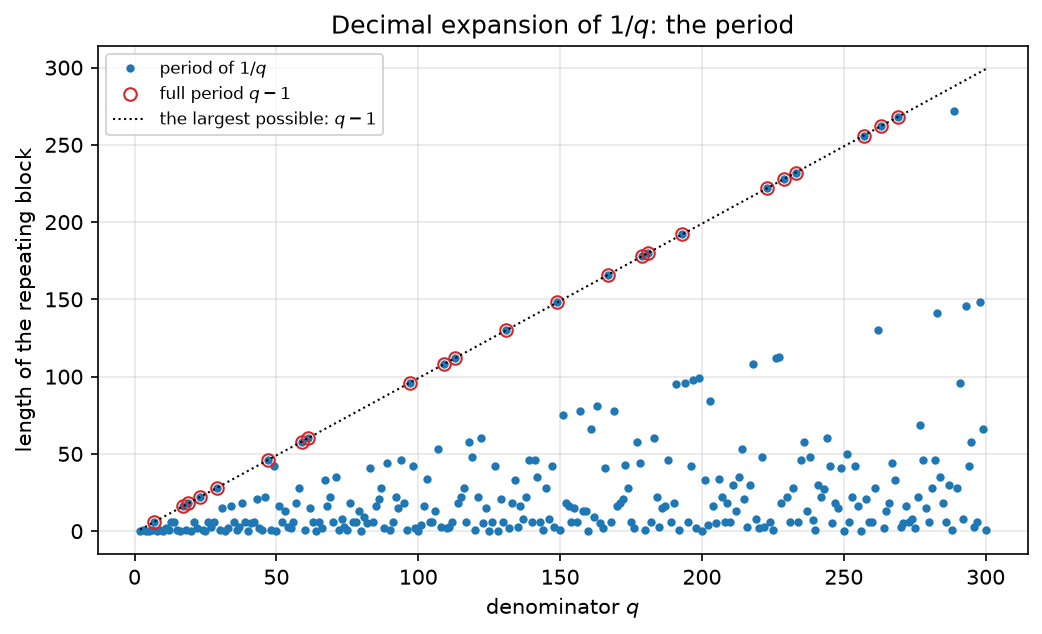

Figure 01f.1 saved as Revision/textbook/figures/01f_1_decimal_periods.png


In [4]:
def only_twos_and_fives(q):
    """True if q has no prime factor other than 2 and 5."""
    for factor in (2, 5):
        while q % factor == 0:
            q //= factor
    return q == 1


qs = list(range(2, 301))
periods = [len(decimal_digits(1, q)[1]) for q in qs]
check(all((period == 0) == only_twos_and_fives(q) for q, period in zip(qs, periods))
      and all(period <= q - 1 for q, period in zip(qs, periods)),
      "1/q ends exactly when q = 2^a 5^b, and the period is at most q - 1 "
      "(q = 2 to 300)")
full = [q for q, period in zip(qs, periods) if period == q - 1]
say(f"q with the full period q - 1: {full[:12]} ... ({len(full)} of them)")
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(qs, periods, ".", color="tab:blue", label="period of $1/q$")
ax.plot(full, [q - 1 for q in full], "o", color="tab:red", fillstyle="none",
        label="full period $q - 1$")
ax.plot([2, 300], [1, 299], "k:", lw=1, label="the largest possible: $q - 1$")
ax.set_xlabel("denominator $q$")
ax.set_ylabel("length of the repeating block")
ax.set_title("Decimal expansion of $1/q$: the period")
ax.legend(loc="upper left", fontsize=8);
save_figure(fig, "decimal_periods",
            "The length of the repeating block (the period) of the decimal digits "
            "of $1/q$ for every denominator $q = 2$ to 300 (blue dots); horizontal "
            "axis $q$, vertical axis the period (a whole number). Dots at 0 are the "
            "denominators $q = 2^a 5^b$, whose decimals end. No dot lies above the "
            "dotted line $q - 1$, because long division has only $q - 1$ nonzero "
            "remainders; the red circles are the primes that reach it.")

## 7. Real numbers: the square root of 2 is not a fraction

**Claim.** No fraction $p/q$ has $(p/q)^2 = 2$. **Proof** by contradiction,
line by line. Suppose $p/q$ is in lowest terms and $p^2/q^2 = 2$. Then

- $p^2 = 2q^2$ (multiply by $q^2$), so $p^2$ is even;
- then $p$ is even (the square of an odd number $2k + 1$ is
  $4k^2 + 4k + 1$, which is odd), so $p = 2r$ for a whole number $r$;
- then $4r^2 = 2q^2$, that is $q^2 = 2r^2$, so $q$ is even as well;
- so 2 divides both $p$ and $q$, and $p/q$ was not in lowest terms: a
  contradiction. Hence $\sqrt 2$ is not a fraction: it is irrational.

The best one can do is to come close. The fractions $p/q$ made by the rule
$p' = p + 2q$, $q' = p + q$ from $1/1$ ($3/2$, $7/5$, $17/12$, $41/29$, ...)
have $p^2 - 2q^2 = \pm 1$, alternating in sign: indeed

$$p'^2 - 2q'^2 = (p + 2q)^2 - 2(p + q)^2 = p^2 + 4pq + 4q^2 - 2p^2 - 4pq - 2q^2
= -(p^2 - 2q^2)$$

(multiply out both squares, then collect the terms). So $p^2/q^2 = 2 \pm
1/q^2$ comes ever closer to 2 without reaching it, and
$p/q - \sqrt 2 = (p^2 - 2q^2)/(q(p + q\sqrt 2))$ (multiply numerator and
denominator by $p + q\sqrt 2$), whose size is about $1/(2\sqrt 2\, q^2)$.

The next cell checks with exact whole numbers that $p^2 = 2q^2$ has no
solution with $q \leq 10{,}000$, lists 12 of these fractions with
$p^2 - 2q^2$ and the error (computed with mpmath at 50 digits), and checks
that error $\cdot\, q^2$ approaches $1/(2\sqrt 2) = 0.35355\dots$

In [5]:
# isqrt(n) is the whole part of the square root of n, computed exactly:
no_solution = all(math.isqrt(2 * q * q) ** 2 != 2 * q * q for q in range(1, 10001))
check(no_solution, "p^2 = 2 q^2 has no solution in whole numbers with q <= 10000")
mpmath.mp.dps = 50  # 50 significant digits
root2 = mpmath.sqrt(2)
convergents = [(1, 1)]
while len(convergents) < 12:
    p, q = convergents[-1]
    convergents.append((p + 2 * q, p + q))  # the rule p' = p + 2q, q' = p + q
for p, q in convergents:
    error = abs(mpmath.mpf(p) / q - root2)
    say(f"{p}/{q}: p^2 - 2 q^2 = {p * p - 2 * q * q:+d}, error "
        f"{mpmath.nstr(error, 3)}, error q^2 = {mpmath.nstr(error * q * q, 6)}")
signs = [p * p - 2 * q * q for p, q in convergents]
check(signs == [(-1) ** (k + 1) for k in range(12)],
      "p^2 - 2 q^2 = -1, +1, -1, ... for the 12 fractions")
p, q = convergents[-1]
limit_value = 1 / (2 * root2)
check(abs(abs(mpmath.mpf(p) / q - root2) * q * q - limit_value) < mpmath.mpf("1e-6"),
      "the error of p/q times q^2 approaches 1/(2 sqrt 2) = 0.35355")

PASS p^2 = 2 q^2 has no solution in whole numbers with q <= 10000
1/1: p^2 - 2 q^2 = -1, error 0.414, error q^2 = 0.414214
3/2: p^2 - 2 q^2 = +1, error 0.0858, error q^2 = 0.343146
7/5: p^2 - 2 q^2 = -1, error 0.0142, error q^2 = 0.355339
17/12: p^2 - 2 q^2 = +1, error 0.00245, error q^2 = 0.353247
41/29: p^2 - 2 q^2 = -1, error 0.00042, error q^2 = 0.353606
99/70: p^2 - 2 q^2 = +1, error 7.22e-5, error q^2 = 0.353544
239/169: p^2 - 2 q^2 = -1, error 1.24e-5, error q^2 = 0.353555
577/408: p^2 - 2 q^2 = +1, error 2.12e-6, error q^2 = 0.353553
1393/985: p^2 - 2 q^2 = -1, error 3.64e-7, error q^2 = 0.353553
3363/2378: p^2 - 2 q^2 = +1, error 6.25e-8, error q^2 = 0.353553
8119/5741: p^2 - 2 q^2 = -1, error 1.07e-8, error q^2 = 0.353553
19601/13860: p^2 - 2 q^2 = +1, error 1.84e-9, error q^2 = 0.353553
PASS p^2 - 2 q^2 = -1, +1, -1, ... for the 12 fractions
PASS the error of p/q times q^2 approaches 1/(2 sqrt 2) = 0.35355


A real number can also be pinned down by **bisection** with fractions only.
Start with $1 < \sqrt 2 < 2$ (because $1^2 < 2 < 2^2$). Take the middle $m$ of
the interval: if $m^2 < 2$ the root lies in the right half, otherwise in the
left half. Each step halves the width, so after 60 steps the width is
$2^{-60} \approx 8.7 \times 10^{-19}$ while both ends are still exact
fractions. The next cell does this and draws the widths (left) and the errors
of the best fraction with each denominator $q = 1, \dots, 1000$ (right).

after 60 halvings: 1.4142135623730950483 < sqrt 2 < 1.4142135623730950492
sqrt 2 with 30 digits: 1.41421356237309504880168872421
PASS 60 halvings: exact fractions low < sqrt 2 < high with high - low = 2^(-60)


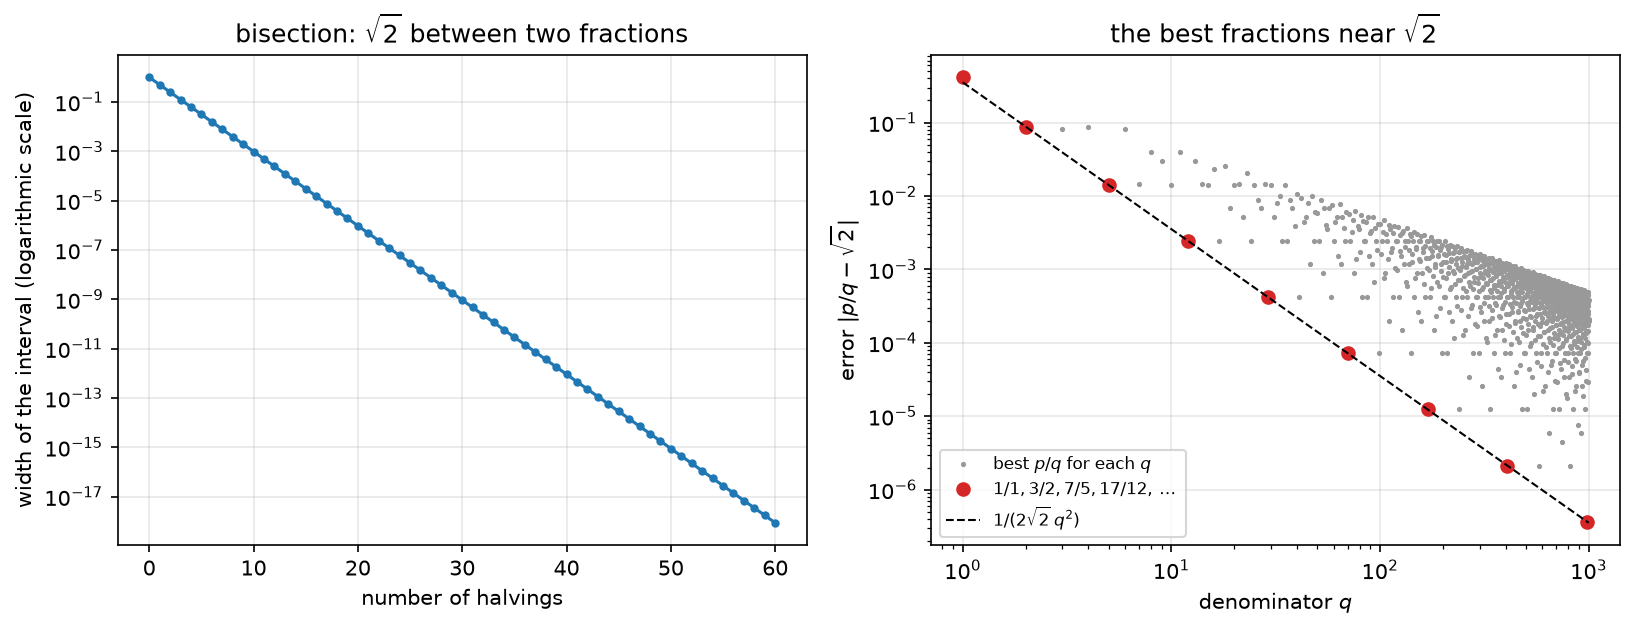

Figure 01f.2 saved as Revision/textbook/figures/01f_2_square_root_of_two.png


In [6]:
low, high = fractions.Fraction(1), fractions.Fraction(2)  # 1^2 < 2 < 2^2
widths = [high - low]
for step in range(60):
    middle = (low + high) / 2
    if middle * middle < 2:
        low = middle  # the root is in the right half
    else:
        high = middle  # the root is in the left half
    widths.append(high - low)
low_mp = mpmath.mpf(low.numerator) / low.denominator
high_mp = mpmath.mpf(high.numerator) / high.denominator
say(f"after 60 halvings: {mpmath.nstr(low_mp, 20)} < sqrt 2 < "
    f"{mpmath.nstr(high_mp, 20)}")
say(f"sqrt 2 with 30 digits: {mpmath.nstr(root2, 30)}")
check(low * low < 2 < high * high and high - low == fractions.Fraction(1, 2 ** 60)
      and low_mp < root2 < high_mp,
      "60 halvings: exact fractions low < sqrt 2 < high with high - low = 2^(-60)")
denominators = np.arange(1, 1001)
best_p = np.rint(denominators * np.sqrt(2.0))  # the nearest numerator for each q
best_error = np.abs(best_p / denominators - np.sqrt(2.0))
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.3))
left.semilogy(range(61), [float(w) for w in widths], "o-", ms=3)
left.set_xlabel("number of halvings")
left.set_ylabel("width of the interval (logarithmic scale)")
left.set_title("bisection: $\\sqrt{2}$ between two fractions")
right.loglog(denominators, best_error, ".", ms=3, color="0.6",
             label="best $p/q$ for each $q$")
conv_q = [q for _, q in convergents if q <= 1000]
conv_error = [float(abs(mpmath.mpf(p) / q - root2)) for p, q in convergents
              if q <= 1000]
right.loglog(conv_q, conv_error, "o", color="tab:red",
             label="$1/1, 3/2, 7/5, 17/12, \\dots$")
right.loglog(denominators, 1 / (2 * np.sqrt(2.0) * denominators ** 2.0), "k--",
             lw=1, label="$1/(2\\sqrt{2}\\,q^2)$")
right.set_xlabel("denominator $q$")
right.set_ylabel("error $|p/q - \\sqrt{2}|$")
right.set_title("the best fractions near $\\sqrt{2}$")
right.legend(fontsize=8, loc="lower left")
fig.tight_layout()
save_figure(fig, "square_root_of_two",
            "Left: the width of the interval between two fractions that contains "
            "$\\sqrt{2}$, after each of 60 halvings (bisection), on a logarithmic "
            "vertical axis: a straight line, because each step halves the width, "
            "down to $2^{-60}$. Right: the error $|p/q - \\sqrt{2}|$ of the best "
            "fraction with denominator $q$ for $q = 1$ to 1000 (grey dots), the "
            "fractions $1/1, 3/2, 7/5, 17/12, \\dots$ made by the rule $p + 2q$, "
            "$p + q$ (red) and the line $1/(2\\sqrt{2}\\,q^2)$ (dashed); both axes "
            "logarithmic, pure numbers. No error is 0: $\\sqrt{2}$ is not a "
            "fraction, but the red fractions come as close as $1/q^2$ allows.")

## 8. Floating-point numbers

A computer stores a real number as a **floating-point number**: a whole number
$m$ of at most 53 bits times a power of two, $m \cdot 2^k$. Fractions whose
denominator is a power of 2, such as $0.5 = 1/2$, are stored exactly; others,
such as $0.1 = 1/10$, are rounded to the nearest such number. That is why
$0.1 + 0.2$ is not exactly $0.3$ in a computer. The next cell shows:

- $0.1 + 0.2$ as Python prints it, and the exact fraction that is stored for
  $0.1$ (`fractions.Fraction(0.1)` reads it out): its denominator is $2^{55}$;
- machine epsilon $\varepsilon = 2^{-52}$: $1 + \varepsilon$ is the next
  floating-point number after 1, and $1 + \varepsilon/2$ is rounded back to 1;
- above $2^{53}$ not even every whole number can be stored:
  $2^{53} + 1$ is rounded to $2^{53}$;
- the step from a number $x$ to the next floating-point number
  (`np.spacing`): writing $x = f \cdot 2^e$ with $\tfrac12 \leq f < 1$
  (`np.frexp` finds $f$ and $e$), the step is exactly $2^{e - 53}$; so it is
  about $\varepsilon x$: the *relative* precision is the same at every size.

In [7]:
total = 0.1 + 0.2
stored = fractions.Fraction(0.1)  # the exact value of the floating-point number 0.1
say(f"0.1 + 0.2 = {total:.17f} (17 digits), and 0.3 = {0.3:.17f}")
say(f"0.1 is stored as {stored.numerator}/{stored.denominator}")
check(total != 0.3 and stored != fractions.Fraction(1, 10)
      and stored.denominator == 2 ** 55,
      "0.1 + 0.2 is not 0.3 in floating point, and 0.1 is stored as a fraction "
      "with the denominator 2^55")
eps = float(np.finfo(float).eps)  # machine epsilon
say(f"machine epsilon = {eps!r} = 2^-52: {eps == 2.0 ** -52}")
check(eps == 2.0 ** -52 and 1.0 + eps != 1.0 and 1.0 + eps / 2 == 1.0,
      "1 + eps is the next number after 1; 1 + eps/2 is rounded back to 1")
check(float(2 ** 53 + 1) == float(2 ** 53) and float(2 ** 53 - 1) != float(2 ** 53),
      "2^53 + 1 cannot be stored: it is rounded to 2^53")
xs = np.logspace(-3, 20, 2301)  # 2301 numbers from 0.001 to 10^20
fraction_part, exponent = np.frexp(xs)  # xs = fraction_part * 2^exponent
predicted = np.ldexp(1.0, exponent - 53)  # 2^(exponent - 53)
check(bool(np.all(np.spacing(xs) == predicted))
      and bool(np.all(np.spacing(xs) <= eps * xs)),
      "the step after x is 2^(e - 53), never more than eps x (2301 values of x)")

0.1 + 0.2 = 0.30000000000000004 (17 digits), and 0.3 = 0.29999999999999999
0.1 is stored as 3602879701896397/36028797018963968
PASS 0.1 + 0.2 is not 0.3 in floating point, and 0.1 is stored as a fraction with the
    denominator 2^55
machine epsilon = 2.220446049250313e-16 = 2^-52: True
PASS 1 + eps is the next number after 1; 1 + eps/2 is rounded back to 1
PASS 2^53 + 1 cannot be stored: it is rounded to 2^53
PASS the step after x is 2^(e - 53), never more than eps x (2301 values of x)


The next cell draws the step size in two ways. Left: the step itself for $x$
from $2^{48}$ to $2^{57}$ (about $2.8 \times 10^{14}$ to $1.4 \times 10^{17}$),
both axes logarithmic with base 2: a staircase, because the step stays the
same between two powers of 2 and doubles at each power of 2; it is 1 between
$2^{52}$ and $2^{53}$ and 2 above $2^{53}$, where odd whole numbers can no
longer be stored. Right: the *relative* step, step divided by $x$, for $x$ from
$10^{-3}$ to $10^{20}$: it always lies between $\varepsilon/2$ and
$\varepsilon$.

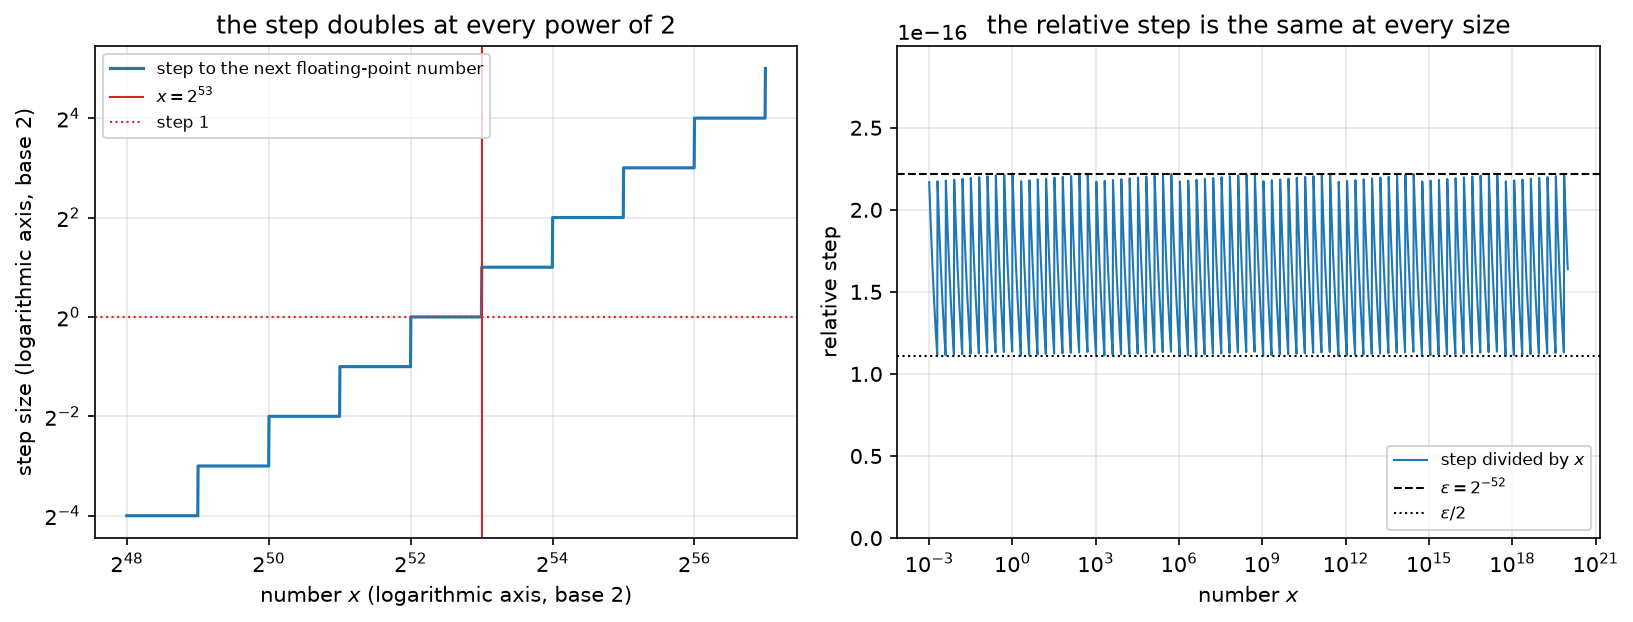

Figure 01f.3 saved as Revision/textbook/figures/01f_3_float_spacing.png


In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.4))
big_x = np.logspace(48, 57, 2000, base=2.0)  # from 2^48 to 2^57
left.loglog(big_x, np.spacing(big_x), color="tab:blue", lw=1.5, base=2,
            label="step to the next floating-point number")
left.axvline(2.0 ** 53, color="tab:red", lw=1, label="$x = 2^{53}$")
left.axhline(1.0, color="tab:red", ls=":", lw=1, label="step 1")
left.set_xlabel("number $x$ (logarithmic axis, base 2)")
left.set_ylabel("step size (logarithmic axis, base 2)")
left.set_title("the step doubles at every power of 2")
left.legend(fontsize=8, loc="upper left")
right.semilogx(xs, np.spacing(xs) / xs, color="tab:blue", lw=1,
               label="step divided by $x$")
right.axhline(eps, color="black", ls="--", lw=1, label="$\\varepsilon = 2^{-52}$")
right.axhline(eps / 2, color="black", ls=":", lw=1, label="$\\varepsilon/2$")
right.set_ylim(0.0, 1.35 * eps)
right.set_xlabel("number $x$")
right.set_ylabel("relative step")
right.set_title("the relative step is the same at every size")
right.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save_figure(fig, "float_spacing",
            "How far apart floating-point numbers are. Left: the distance from a "
            "number $x$ to the next floating-point number for $x$ from $2^{48}$ to "
            "$2^{57}$, both axes logarithmic with base 2: a staircase that doubles "
            "at every power of 2; right of the red line $x = 2^{53}$ the step is 2, "
            "so odd whole numbers are skipped there. Right: the step divided by "
            "$x$ for $x$ from $10^{-3}$ to $10^{20}$ (logarithmic horizontal axis): "
            "a sawtooth that always stays between $\\varepsilon/2$ (dotted) and "
            "$\\varepsilon = 2^{-52} \\approx 2.2 \\times 10^{-16}$ (dashed), the "
            "relative precision of every floating-point number.")

## 9. Rounding and cancellation

The function $f(x) = (1 - \cos x)/x^2$ tends to $\tfrac12$ as $x$ tends to 0.
Computed as written, it fails for small $x$: $\cos x$ is very close to 1, its
rounding error is about $\varepsilon$, and the subtraction $1 - \cos x$ keeps
this error while the true value $1 - \cos x \approx x^2/2$ is tiny. The
relative error is then about $\varepsilon/(x^2/2)$; for $x = 10^{-8}$,
$\cos x$ is rounded to exactly 1 and the result is 0, all digits lost. This
is **cancellation**.

The cure is to rewrite the formula without the subtraction. The half-angle
formula $\cos(2y) = 1 - 2\sin^2 y$ (from $\cos(2y) = \cos^2 y - \sin^2 y$ and
$\cos^2 y = 1 - \sin^2 y$) with $y = x/2$ gives
$1 - \cos x = 2\sin^2(x/2)$, so

$$f(x) = \frac{2\sin^2(x/2)}{x^2},$$

which has no subtraction. The next cell checks the limit and the identity with
sympy, computes both formulas at 361 values of $x$ from $10^{-9}$ to 1,
compares them with mpmath at 50 digits, and plots the relative errors.

sympy: the limit of (1 - cos x)/x^2 at x = 0 is 1/2
PASS the limit is 1/2, and 1 - cos x = 2 sin(x/2)^2 exactly
RESULT largest relative error of 2 sin(x/2)^2/x^2 = 4.4e-16
RESULT largest relative error of (1 - cos x)/x^2 = 1.0e+00
PASS the rewritten formula is correct to 1e-15 at all 361 values of x
PASS the formula as written gives 0 at x = 1e-8: cancellation destroyed every digit


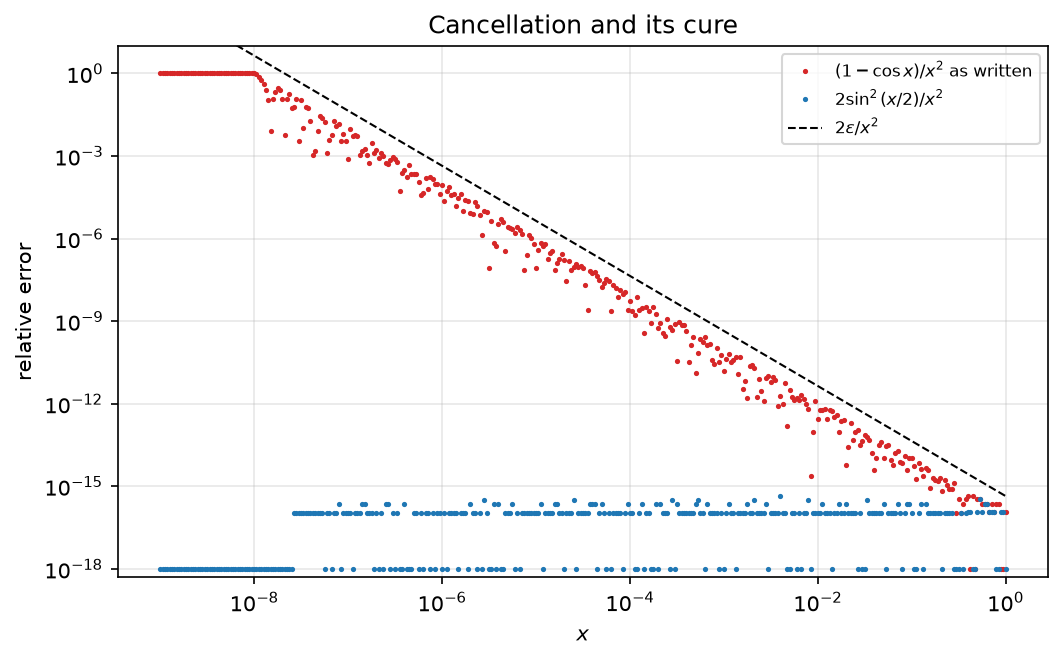

Figure 01f.4 saved as Revision/textbook/figures/01f_4_cancellation.png


In [9]:
x = sp.Symbol("x", positive=True)
limit_at_zero = sp.limit((1 - sp.cos(x)) / x ** 2, x, 0)
say(f"sympy: the limit of (1 - cos x)/x^2 at x = 0 is {limit_at_zero}")
check(limit_at_zero == sp.Rational(1, 2)
      and sp.simplify(1 - sp.cos(x) - 2 * sp.sin(x / 2) ** 2) == 0,
      "the limit is 1/2, and 1 - cos x = 2 sin(x/2)^2 exactly")
x_values = np.logspace(-9, 0, 361)
naive = (1 - np.cos(x_values)) / x_values ** 2
stable = 2 * np.sin(x_values / 2) ** 2 / x_values ** 2
mpmath.mp.dps = 50
exact = np.array([float((1 - mpmath.cos(mpmath.mpf(v))) / mpmath.mpf(v) ** 2)
                  for v in x_values.tolist()])  # mpf(v) is the stored value of v
error_naive = np.abs(naive - exact) / exact
error_stable = np.abs(stable - exact) / exact
report("largest relative error of 2 sin(x/2)^2/x^2", f"{error_stable.max():.1e}")
report("largest relative error of (1 - cos x)/x^2", f"{error_naive.max():.1e}")
check(float(error_stable.max()) < 1e-15,
      "the rewritten formula is correct to 1e-15 at all 361 values of x")
check((1 - math.cos(1e-8)) / 1e-8 ** 2 == 0.0
      and float(error_naive[x_values <= 1e-4].max()) > 1e-3,
      "the formula as written gives 0 at x = 1e-8: cancellation destroyed every digit")
fig, ax = plt.subplots(figsize=(8.0, 4.6))
floor = 1e-18  # an error 0 is drawn at the bottom of the axis
ax.loglog(x_values, np.maximum(error_naive, floor), ".", ms=3, color="tab:red",
          label="$(1 - \\cos x)/x^2$ as written")
ax.loglog(x_values, np.maximum(error_stable, floor), ".", ms=3, color="tab:blue",
          label="$2\\sin^2(x/2)/x^2$")
ax.loglog(x_values, 2 * eps / x_values ** 2, "k--", lw=1,
          label="$2\\varepsilon/x^2$")
ax.set_ylim(0.5 * floor, 10.0)
ax.set_xlabel("$x$")
ax.set_ylabel("relative error")
ax.set_title("Cancellation and its cure")
ax.legend(fontsize=8, loc="upper right");
save_figure(fig, "cancellation",
            "The relative error of two formulas for $(1 - \\cos x)/x^2$ against $x$ "
            "from $10^{-9}$ to 1, both axes logarithmic, compared with 50-digit "
            "arithmetic. Red: the formula as written loses digits like "
            "$2\\varepsilon/x^2$ (dashed line) and gives an error of 100 per cent "
            "for $x$ below about $10^{-8}$. Blue: the same function written as "
            "$2\\sin^2(x/2)/x^2$ stays correct to about $10^{-16}$ (errors that "
            "are exactly 0 are drawn at the bottom of the axis).")

## 10. Powers and roots: the length factors of the author's metric

For positive $a, b$ and any real $p, q$ the laws of powers are

$$a^p a^q = a^{p+q},\quad (a^p)^q = a^{pq},\quad (ab)^p = a^p b^p,\quad
a^{-p} = \frac{1}{a^p},\quad \sqrt a = a^{1/2}.$$

They need $a, b > 0$. For a negative number they can fail:
$\sqrt{(-2)^2} = \sqrt 4 = 2$, not $-2$; in general $\sqrt{x^2} = |x|$.

A worked example with $s > 0$ and real $a$:

$$\frac{1}{\sqrt{s^{1/3}/e^{2a}}} = \Big(\frac{s^{1/3}}{e^{2a}}\Big)^{-1/2}
= \frac{(s^{1/3})^{-1/2}}{(e^{2a})^{-1/2}} = \frac{s^{-1/6}}{e^{-a}}
= \frac{e^{a}}{s^{1/6}}$$

(the root is the power $1/2$ and one over it the power $-1/2$; the power of a
quotient is the quotient of the powers; $(a^p)^q = a^{pq}$ twice; one over
$e^{-a}$ is $e^a$).

**The length factors.** The length of a small step $dx$ along one coordinate
is $\sqrt{|g_{\mu\mu}|}\,dx$. For $0 < z < \pi/2$ both $\sin z$ and $\cos z$
are positive, so the laws apply:

$$\sqrt{e^{2a_4}\sin^{1/3} z} = e^{a_4}\sin^{1/6} z,\quad
\sqrt{e^{-2a_4}\sin^{1/3} z} = e^{-a_4}\sin^{1/6} z,\quad \sqrt{1} = 1,\quad
\sqrt{\cot^2 z} = \cot z,$$

and their product over the eight directions is

$$(e^{a_4}\sin^{1/6} z)^3 \cdot 1 \cdot (e^{-a_4}\sin^{1/6} z)^3 \cdot \cot z
= e^{3a_4 - 3a_4}\,\sin^{6/6} z\,\cot z = \sin z \cot z = \cos z,$$

the record's `sqrtAbsDetG` ($\sin z \cot z$). The next cell checks the laws and
the example with sympy (with symbols declared positive or real), then reads the
metric from the record with the symbols $S = \sin z$ and $C = \cos z$ (both
positive, $\cot z = C/S$), takes the square root of the size of every entry
(the sign of entry $\mu$ is $\eta_{\mu\mu}$ of the frame metric), and checks the
eight factors and their product.

In [10]:
a, b = sp.symbols("a b", positive=True)
p_sym, q_sym = sp.symbols("p q", real=True)
laws = [a ** p_sym * a ** q_sym - a ** (p_sym + q_sym),
        (a ** p_sym) ** q_sym - a ** (p_sym * q_sym),
        (a * b) ** p_sym - a ** p_sym * b ** p_sym,
        a ** (-p_sym) - 1 / a ** p_sym,
        sp.sqrt(a) - a ** sp.Rational(1, 2)]
check(all(sp.simplify(law) == 0 for law in laws),
      "the five laws of powers hold for positive a, b and real p, q")
y = sp.Symbol("y", real=True)  # a real number of either sign
say(f"sympy: sqrt(y^2) = {sp.sqrt(y ** 2)}; numbers: sqrt((-2)^2) = "
    f"{((-2.0) ** 2) ** 0.5}")
check(sp.sqrt(y ** 2) == sp.Abs(y) and ((-2.0) ** 2) ** 0.5 == 2.0,
      "sqrt(y^2) = |y|: for negative numbers the law (a^p)^q = a^(pq) fails")
s_pos, a_real = sp.Symbol("s", positive=True), sp.Symbol("a", real=True)
example = 1 / sp.sqrt(s_pos ** sp.Rational(1, 3) / sp.exp(2 * a_real))
check(sp.simplify(example - sp.exp(a_real) / s_pos ** sp.Rational(1, 6)) == 0,
      "1/sqrt(s^(1/3)/e^(2a)) = e^a/s^(1/6)")

PASS the five laws of powers hold for positive a, b and real p, q
sympy: sqrt(y^2) = Abs(y); numbers: sqrt((-2)^2) = 2.0
PASS sqrt(y^2) = |y|: for negative numbers the law (a^p)^q = a^(pq) fails
PASS 1/sqrt(s^(1/3)/e^(2a)) = e^a/s^(1/6)


The next cell applies the laws to the author's metric as stored in the
Revision record.

In [11]:
S, C = sp.symbols("S C", positive=True)  # S = sin z, C = cos z, both > 0
a4 = sp.Symbol("a4", real=True)  # the value of a4(x4) at one time


def from_record(text):
    """The record's Mathematica text as sympy, with sin z = S and cot z = C/S."""
    text = text.replace("a4[x4]", "a4").replace("Sin[6*H*x8]", "S")
    text = text.replace("Cot[6*H*x8]", "(C/S)").replace("^", "**")
    return sp.sympify(text, locals={"a4": a4, "S": S, "C": C, "E": sp.E})


curvature = json.loads(repository_file("Revision/gkd_lovelock/results/curvature.json")
                       .read_text(encoding="utf-8"))
eta = json.loads(repository_file("Revision/algebra/gammas.json")
                 .read_text(encoding="utf-8"))["eta"]  # +1 or -1 for x1 ... x8
metric = [from_record(text) for text in curvature["metricDiagonal"]]
sizes = [eta[mu] * metric[mu] for mu in range(8)]  # |g_mu mu| = eta_mu mu g_mu mu
check(all(size.is_positive for size in sizes),
      "every entry of the metric has the sign of eta: eta_mu mu g_mu mu > 0")
factors = [sp.sqrt(size) for size in sizes]  # the length factors
expected = ([sp.exp(a4) * S ** sp.Rational(1, 6)] * 3 + [sp.Integer(1)]
            + [sp.exp(-a4) * S ** sp.Rational(1, 6)] * 3 + [C / S])
for mu in range(8):
    say(f"x{mu + 1}: g = {metric[mu]}, length factor {factors[mu]}")
check(all(sp.simplify(f - e) == 0 for f, e in zip(factors, expected)),
      "the length factors: e^a4 S^(1/6) for x1 to x3, 1 for x4, e^(-a4) S^(1/6) "
      "for x5 to x7, cot z = C/S for x8")
product = sp.simplify(sp.Mul(*factors))
record_root = sp.simplify(from_record(curvature["sqrtAbsDetG"]))
say(f"product of the eight factors = {product}; the record's sqrtAbsDetG = "
    f"{record_root}")
lovelock_report = json.loads(repository_file(
    "Revision/gkd_lovelock/results/python-lovelock-report.json")
    .read_text(encoding="utf-8"))
root_verdict = {c["name"]: c["verdict"]
                for c in lovelock_report["checks"]}["sqrt_abs_det_g"]
check(product == C and record_root == C and root_verdict == "PASS",
      "the product of the length factors is cos z, the record's sqrt|det g| = "
      "sin z cot z, for every a4",
      record="Revision/gkd_lovelock/results/curvature.json, sqrtAbsDetG; "
             "python-lovelock-report.json, check sqrt_abs_det_g")

PASS every entry of the metric has the sign of eta: eta_mu mu g_mu mu > 0
x1: g = S**(1/3)*exp(2*a4), length factor S**(1/6)*exp(a4)
x2: g = S**(1/3)*exp(2*a4), length factor S**(1/6)*exp(a4)
x3: g = S**(1/3)*exp(2*a4), length factor S**(1/6)*exp(a4)
x4: g = -1, length factor 1
x5: g = -S**(1/3)*exp(-2*a4), length factor S**(1/6)*exp(-a4)
x6: g = -S**(1/3)*exp(-2*a4), length factor S**(1/6)*exp(-a4)
x7: g = -S**(1/3)*exp(-2*a4), length factor S**(1/6)*exp(-a4)
x8: g = C**2/S**2, length factor C/S
PASS the length factors: e^a4 S^(1/6) for x1 to x3, 1 for x4, e^(-a4) S^(1/6) for x5 to
    x7, cot z = C/S for x8
product of the eight factors = C; the record's sqrtAbsDetG = C
PASS the product of the length factors is cos z, the record's sqrt|det g| = sin z cot z,
    for every a4
     reproduces Revision/gkd_lovelock/results/curvature.json, sqrtAbsDetG; python-
    lovelock-report.json, check sqrt_abs_det_g


## 11. The exponential function, the logarithm and logarithmic axes

The number $e$ is the limit of $(1 + 1/n)^n$ for ever larger $n$ (the growth of
1 unit of money at the interest rate 100 per cent per year, paid in $n$ parts).
The error $e - (1 + 1/n)^n$ is about $e/(2n)$ for large $n$. With 50-digit
arithmetic this is what one sees. With floating-point numbers the formula
breaks down for large $n$: $1 + 1/n$ is rounded (by up to $\varepsilon/2$),
and the power $n$ multiplies that rounding error by about $n$; for
$n = 10^{16}$, $1 + 1/n$ is rounded to exactly 1, and $1^n = 1$.

The logarithm undoes the exponential, $\ln(e^t) = t$, and turns products into
sums, $\ln(xy) = \ln x + \ln y$ for positive $x, y$ (because
$e^{\ln x + \ln y} = e^{\ln x}e^{\ln y} = xy$). In the author's metric the
length factors contain $e^{a_4}$ (space) and $e^{-a_4}$ (extra times). When
$a_4$ grows by $\ln 2 \approx 0.693$, $e^{a_4}$ doubles and
$e^{-a_4}$ halves: $e^{-(a_4 + \ln 2)} = e^{-a_4} e^{-\ln 2} = e^{-a_4}/2$. To
shrink the extra times by a factor 1000, $a_4$ must grow by
$\ln 1000 \approx 6.91$.

The next cell computes the errors for $n = 1, 10, \dots, 10^{16}$ both ways,
checks the $e/(2n)$ law (within 1 per cent for $n \geq 1000$) and the
breakdown of the floating-point version, and checks the laws of the logarithm.

In [12]:
mpmath.mp.dps = 50
n_values = [10 ** k for k in range(17)]
error_exact = [abs((1 + mpmath.mpf(1) / n) ** n - mpmath.e) for n in n_values]
error_float = [abs((1.0 + 1.0 / n) ** n - math.e) for n in n_values]
for k in (0, 3, 6, 9, 12, 16):
    say(f"n = 10^{k:2d}: 50 digits: error {mpmath.nstr(error_exact[k], 3):>8}; "
        f"floating point: error {error_float[k]:.1e}")
ratios = [error_exact[k] * n_values[k] / (mpmath.e / 2) for k in range(3, 17)]
check(all(abs(r - 1) < mpmath.mpf("0.01") for r in ratios),
      "50 digits: the error of (1 + 1/n)^n is e/(2n) within 1 per cent for n >= 1000")
check(error_float[16] == math.e - 1 and error_float[16] > 1e3 * error_float[6],
      "floating point: for n = 10^16, 1 + 1/n is rounded to 1, and the error grows "
      "to e - 1")
t_sym = sp.Symbol("t", real=True)
u, w = sp.symbols("u w", positive=True)
check(sp.log(sp.exp(t_sym)) == t_sym
      and sp.expand_log(sp.log(u * w)) == sp.log(u) + sp.log(w)
      and sp.simplify(sp.exp(-(a4 + sp.log(2))) - sp.exp(-a4) / 2) == 0,
      "ln(e^t) = t, ln(u w) = ln u + ln w, and e^(-(a4 + ln 2)) = e^(-a4)/2")
report("growth of a4 that shrinks the extra times by a factor 1000",
       f"{math.log(1000):.4f}")

n = 10^ 0: 50 digits: error    0.718; floating point: error 7.2e-01
n = 10^ 3: 50 digits: error  0.00136; floating point: error 1.4e-03
n = 10^ 6: 50 digits: error  1.36e-6; floating point: error 1.4e-06
n = 10^ 9: 50 digits: error  1.36e-9; floating point: error 2.2e-07
n = 10^12: 50 digits: error 1.36e-12; floating point: error 2.4e-04
n = 10^16: 50 digits: error 1.36e-16; floating point: error 1.7e+00
PASS 50 digits: the error of (1 + 1/n)^n is e/(2n) within 1 per cent for n >= 1000
PASS floating point: for n = 10^16, 1 + 1/n is rounded to 1, and the error grows to e - 1
PASS ln(e^t) = t, ln(u w) = ln u + ln w, and e^(-(a4 + ln 2)) = e^(-a4)/2
RESULT growth of a4 that shrinks the extra times by a factor 1000 = 6.9078


The next cell draws the errors of the limit for $e$ (figure 5) and the two
factors $e^{a_4}$ and $e^{-a_4}$ on an ordinary and on a logarithmic vertical
axis (figure 6), with the points $a_4 = 0, \ln 2, 2\ln 2, \dots$ where they
double and halve.

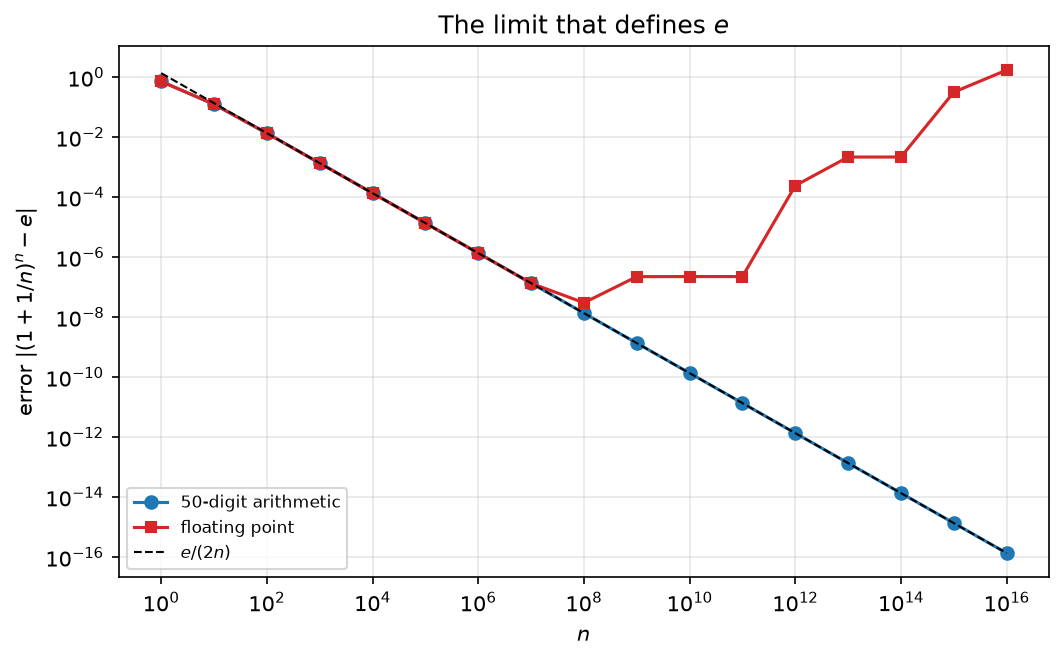

Figure 01f.5 saved as Revision/textbook/figures/01f_5_limit_for_e.png


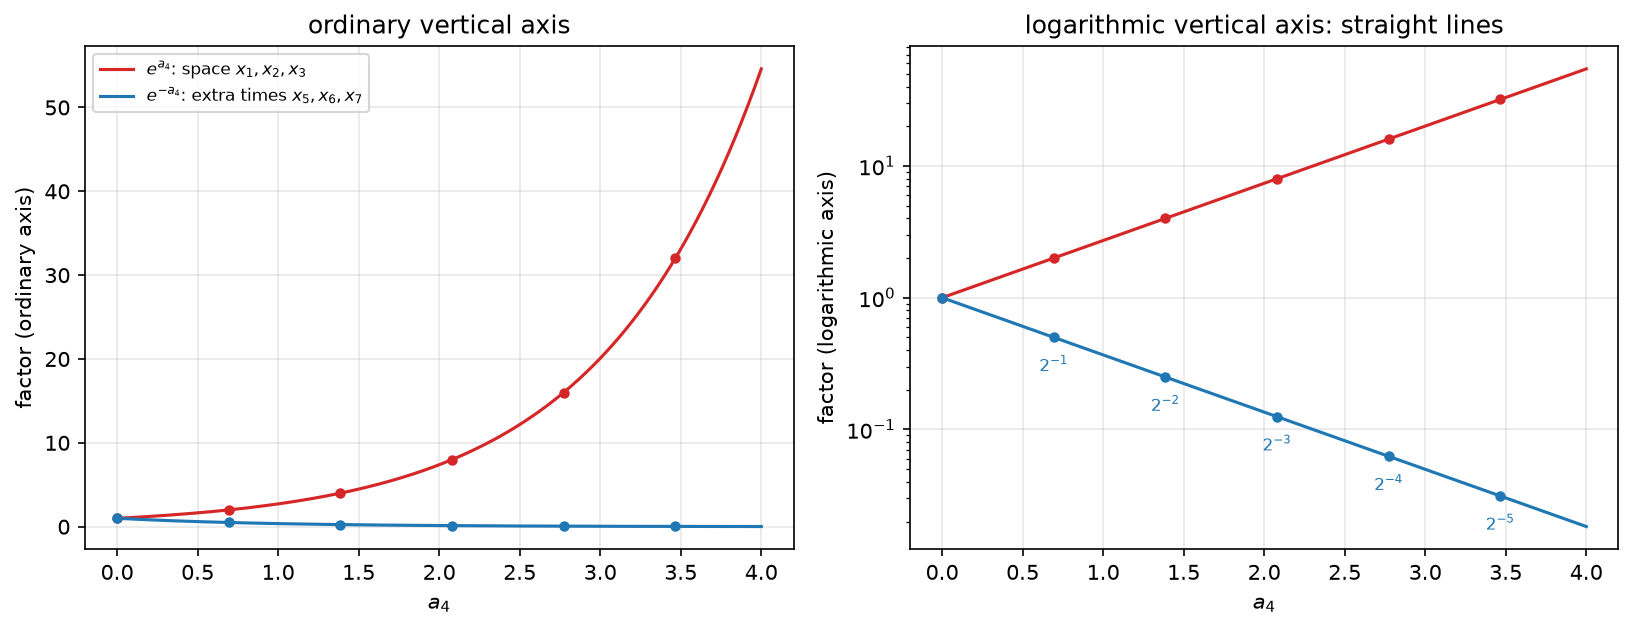

Figure 01f.6 saved as Revision/textbook/figures/01f_6_growth_and_deflation.png


In [13]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.loglog(n_values, [float(e) for e in error_exact], "o-", color="tab:blue",
          label="50-digit arithmetic")
ax.loglog(n_values, error_float, "s-", color="tab:red", ms=5,
          label="floating point")
ax.loglog(n_values, [math.e / (2 * n) for n in n_values], "k--", lw=1,
          label="$e/(2n)$")
ax.set_xlabel("$n$")
ax.set_ylabel("error $|(1 + 1/n)^n - e|$")
ax.set_title("The limit that defines $e$")
ax.legend(fontsize=8, loc="lower left");
save_figure(fig, "limit_for_e",
            "The error of $(1 + 1/n)^n$ as an approximation of $e$ for $n = 1$ to "
            "$10^{16}$, both axes logarithmic. Blue: with 50-digit arithmetic the "
            "error falls like $e/(2n)$ (dashed line). Red: with floating-point "
            "numbers it falls only until $n$ is about $10^8$; then the rounding of "
            "$1 + 1/n$, multiplied by the power $n$, takes over, and at $n = "
            "10^{16}$ the result is exactly 1, an error of $e - 1$.")
a4_values = np.linspace(0.0, 4.0, 401)
marks = np.log(2.0) * np.arange(6)  # a4 = 0, ln 2, 2 ln 2, ..., 5 ln 2
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.3))
for ax in (left, right):
    ax.plot(a4_values, np.exp(a4_values), color="tab:red",
            label="$e^{a_4}$: space $x_1, x_2, x_3$")
    ax.plot(a4_values, np.exp(-a4_values), color="tab:blue",
            label="$e^{-a_4}$: extra times $x_5, x_6, x_7$")
    ax.plot(marks, np.exp(marks), "o", color="tab:red", ms=4)
    ax.plot(marks, np.exp(-marks), "o", color="tab:blue", ms=4)
    ax.set_xlabel("$a_4$")
left.set_ylabel("factor (ordinary axis)")
left.set_title("ordinary vertical axis")
left.legend(fontsize=8, loc="upper left")
right.set_yscale("log")
right.set_ylabel("factor (logarithmic axis)")
right.set_title("logarithmic vertical axis: straight lines")
for k in range(1, 6):
    right.text(marks[k], np.exp(-marks[k]) * 0.55, f"$2^{{-{k}}}$", ha="center",
               fontsize=8, color="tab:blue")
fig.tight_layout()
save_figure(fig, "growth_and_deflation",
            "The factors $e^{a_4}$ (red), which multiply the lengths along the three "
            "space directions, and $e^{-a_4}$ (blue), which multiply the lengths "
            "along the three extra times, for $a_4$ from 0 to 4 (the factor "
            "$\\sin^{1/6} z$, which depends on the hidden coordinate $x_8$, is "
            "left out); horizontal axis $a_4$, vertical axis "
            "the factor (a pure number), ordinary on the left and logarithmic on "
            "the right. The dots mark $a_4 = 0, \\ln 2, 2\\ln 2, \\dots$, where "
            "$e^{a_4}$ doubles and $e^{-a_4}$ halves. On the logarithmic axis both "
            "are straight lines, one rising and one falling equally fast: the "
            "extra times deflate exponentially as $a_4$ grows.")

## 12. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [14]:
figure_names = ["01f_1_decimal_periods.png", "01f_2_square_root_of_two.png",
                "01f_3_float_spacing.png", "01f_4_cancellation.png",
                "01f_5_limit_for_e.png", "01f_6_growth_and_deflation.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 26 CHECKS PASSED (notebook 01f)


## 13. What this notebook showed

- Whole numbers and fractions are computed exactly by Python ($2^{100}$, $16!$,
  $1/3 + 1/6 = 1/2$, $84/126 = 2/3$).
- The decimal digits of a fraction end or repeat, with a period of at most
  $q - 1$; they end exactly when $q = 2^a 5^b$.
- $\sqrt 2$ is not a fraction (proved); bisection pins it between exact
  fractions to $2^{-60}$, and the fractions $1/1, 3/2, 7/5, \dots$ with
  $p^2 - 2q^2 = \pm 1$ approach it with errors close to $1/(2\sqrt2\,q^2)$.
- A computer stores real numbers as floating-point numbers with a relative
  precision of about $\varepsilon = 2^{-52}$: $0.1 + 0.2 \neq 0.3$, and above
  $2^{53}$ whole numbers are skipped. Subtracting nearly equal numbers loses
  digits (cancellation); rewriting $1 - \cos x$ as $2\sin^2(x/2)$ cures it.
- The laws of powers hold for positive bases, and $\sqrt{y^2} = |y|$. Applied
  to the author's metric of the Revision record they give the length factors
  $e^{a_4}\sin^{1/6} z$ (space), 1 (time), $e^{-a_4}\sin^{1/6} z$ (the
  exponentially deflating extra times) and $\cot z$ (hidden direction), whose
  product is $\cos z$, the record's $\sqrt{|\det g|}$, for every $a_4$.
- $e$ is the limit of $(1 + 1/n)^n$, with the error $e/(2n)$; floating point
  breaks this limit for $n$ beyond about $10^8$. A growth of $a_4$ by $\ln 2$
  doubles $e^{a_4}$ and halves $e^{-a_4}$; on a logarithmic axis both are
  straight lines.